## Name: Faruk Muritala

## Deep Learning: Transfer Learning

## Use Case: ArtWork Classification

In [30]:
#Downloading the WikiArt Dataset from Huggingface.
import requests
import json
import threading

def download_file(url, file_name):
    print(f'File downloading: {url}')
    with requests.get(url, stream=True, allow_redirects=True) as response:
        # Check if the request was successful
        if response.status_code == 200:
            # Stream the content to a file
            with open(file_name, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:  # filter out keep-alive new chunks
                        f.write(chunk)
            print(f'File downloaded: {file_name}')
        else:
            print(f'Failed to download file: status code {response.status_code}')


def download_in_parallel(content):
    file_urls = json.loads(content)
    threads = []
    # Start a new thread for each command
    for url in file_urls:
        file_name = url.split('/')[-1]
        thread = threading.Thread(target=download_file, args=(url,file_name))
        thread.start()
        threads.append(thread)

    # Wait for all threads to complete
    for thread in threads:
        thread.join()


# The URL you want to access as a string
url_string = 'https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train'

# Use the requests library to perform a GET request to the URL
response = requests.get(url_string)

# Check if the request was successful
if response.ok:
    # The content of the response
    content = response.content.decode('utf-8')
    print("Success")
    download_in_parallel(content)
else:
    print("Failed to access the URL with status code:", response.status_code)

Success
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/0.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/1.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/2.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/3.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/4.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/5.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/6.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/7.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/default/train/8.parquet
File downloading: https://huggingface.co/api/datasets/huggan/wikiart/parquet/defaul

In [2]:
!pip install pyarrow

In [3]:
# Import necessary libraries
import os
import pandas as pd
from PIL import Image  # Import the Image class
from sklearn.model_selection import train_test_split
import numpy as np
import io
import pyarrow.parquet as pq

# Define the number of samples per category you want to subset
samples_per_category = 50

# List all files in the current working directory
files = os.listdir()

# Filter the files to include only those with the ".parquet" extension
parquet_files = [file for file in files if file.endswith('.parquet')]

# Initialize empty lists for images and labels
images = []
labels = []

# Read each parquet file and extract images and labels
for file in parquet_files:
    # Read the parquet file
    parquet_file = pq.read_table(file)

    # Extract the image and label columns
    image_column = parquet_file['image']
    label_column = parquet_file['genre']

    # Assuming image paths are stored in 'image_column'
    image_paths = image_column.to_pandas().tolist()

    # Select only the specified number of samples per category
    selected_paths = image_paths[:samples_per_category]

    # Append the selected image data and labels to the lists
    images.extend(selected_paths)
    labels.extend(label_column[:samples_per_category].to_pandas().tolist())

# Create a DataFrame from the lists
total_dataset = pd.DataFrame({'image': images, 'genre': labels})

# Extract file paths from dictionaries and overwrite the 'image' column
total_dataset['image'] = total_dataset['image'].apply(lambda x: Image.open(io.BytesIO(x['bytes'])))

# Split the data into 80% training, 10% validation, and 10% testing
train_data, test_data = train_test_split(total_dataset, test_size=0.2, random_state=42)
train_data, valid_data = train_test_split(train_data, test_size=0.1, random_state=42)

# Assuming you have image paths in a column named 'image', you can access them like this
train_images = train_data['image'].values
valid_images = valid_data['image'].values
test_images = test_data['image'].values

# Now you can use these images
# Example:
train_images[0].show()


In [4]:
# We have a DataFrame named total_dataset
unique_categories = total_dataset['genre'].unique()
print("Unique Categories:", unique_categories)


Unique Categories: [ 4  6  7  9 10  8  2  1  5  3  0]


In [5]:
# Count of  unique categories in 'total_dataset' DataFrame
category_counts = parquet_file['genre'].value_counts()

# Print the frequency of each unique category
print("Category Frequencies:")
print(category_counts)

Category Frequencies:
-- is_valid: all not null
-- child 0 type: int64
  [
    8,
    2,
    4,
    6,
    10,
    7,
    9,
    3,
    1,
    0,
    5
  ]
-- child 1 type: int64
  [
    108,
    184,
    275,
    168,
    152,
    74,
    37,
    36,
    81,
    1,
    16
  ]


In [6]:
# import Necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dropout, BatchNormalization
import matplotlib.pyplot as plt

In [7]:
# we have 'genre' column in the dataframes
le = LabelEncoder()
train_labels = to_categorical(le.fit_transform(train_data['genre']))
valid_labels = to_categorical(le.transform(valid_data['genre']))
test_labels = to_categorical(le.transform(test_data['genre']))

# Number classes based on dataset
num_classes = 11

# Data Preprocessing
target_size = (224, 224)
train_images_preprocessed = [img.resize(target_size) for img in train_images]
train_images_array = np.array([np.array(img) / 255.0 for img in train_images_preprocessed])

valid_images_preprocessed = [img.resize(target_size) for img in valid_images]
valid_images_array = np.array([np.array(img) / 255.0 for img in valid_images_preprocessed])

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

output_dir = '/content/gdrive/MyDrive/ArtworkClassifier/'


Mounted at /content/gdrive


Step by step VGG16 implementation in Keras
# Step by step VGG16 implementation in Keras

VGG16 is a convolution neural net (CNN ) architecture which was used to win ILSVR(Imagenet) competition in 2014.
It is considered to be one of the excellent vision model architecture till date. Most unique thing about VGG16
is that instead of having a large number of hyper-parameter they focused on having convolution layers of 3x3
filter with a stride 1 and always used same padding and maxpool layer of 2x2 filter of stride 2.
It follows this arrangement of convolution and max pool layers consistently throughout the whole architecture.
In the end it has 2 FC(fully connected layers) followed by a softmax for output. The 16 in VGG16 refers to it has
16 layers that have weights. This network is a pretty large network and it has about 138 million (approx) parameters.

Very Deep Convolutional Networks for Large-Scale Image Recognition. [https://arxiv.org/abs/1409.1556]

![vgg16 architecture](https://user-images.githubusercontent.com/35737777/69682136-5bdd4780-10a8-11ea-9079-50283f5451df.png)

The implementation of VGG16 is has follows.


In [9]:
# Define lists to store training history and configurations
histories = []
configurations = []

# Model Building (using VGG16 as an example)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Experiment with different configurations
dropout_rates = [0.01] #[0.05, 0.01, 0.001]
batch_norm_positions =  ['after_dense'] # ['before_dense', 'after_dense']

for dropout_rate in dropout_rates:
    for batch_norm_position in batch_norm_positions:
        model = Sequential()
        model.add(base_model)
        model.add(Flatten())
        model.add(Dense(256, activation='relu'))

        if batch_norm_position == 'before_dense':
            model.add(BatchNormalization())

        model.add(Dropout(dropout_rate))

        if batch_norm_position == 'after_dense':
            model.add(BatchNormalization())

        model.add(Dense(num_classes, activation='softmax'))

        # Transfer Learning
        base_model.trainable = False

        # Compile the Model
        model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

        # Print the configuration for reference
        configuration_name = f"Dropout={dropout_rate}, Batch Norm Position={batch_norm_position}"
        configurations.append(configuration_name)
        print(f"Configuration: {configuration_name}")

        # Train the model and evaluate base on need
        # Training
        # Data Augmentation: Create an ImageDataGenerator instance with augmentation settings
        datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )

        # Applying data augmentation during the training
        train_generator = datagen.flow(train_images_array, train_labels, batch_size=32)

        # Training the model with data augmentation
        history = model.fit(train_generator, epochs=9, validation_data=(valid_images_array, valid_labels))

        # Save the training history
        histories.append(history)

        # Evaluation
        test_images_preprocessed = [img.resize(target_size) for img in test_images]
        test_images_array = np.array([np.array(img) / 255.0 for img in test_images_preprocessed])

        test_labels = to_categorical(le.transform(test_data['genre']))
        accuracy = model.evaluate(test_images_array, test_labels)
        print(f'Test Accuracy: {accuracy[1]}')



58889256/58889256 [==============================] - 0s 0us/step
Configuration: Dropout=0.01, Batch Norm Position=after_dense
Epoch 1/9
12/12 [==============================] - 283s 24s/step - loss: 2.5882 - accuracy: 0.3194 - val_loss: 5.2035 - val_accuracy: 0.1500
Epoch 2/9
12/12 [==============================] - 249s 21s/step - loss: 1.6537 - accuracy: 0.4778 - val_loss: 5.0054 - val_accuracy: 0.1500
Epoch 3/9
12/12 [==============================] - 244s 20s/step - loss: 1.4242 - accuracy: 0.5472 - val_loss: 4.2644 - val_accuracy: 0.2250
Epoch 4/9
12/12 [==============================] - 254s 21s/step - loss: 1.1647 - accuracy: 0.6278 - val_loss: 3.7716 - val_accuracy: 0.2750
Epoch 5/9
12/12 [==============================] - 252s 22s/step - loss: 1.1125 - accuracy: 0.6250 - val_loss: 3.2626 - val_accuracy: 0.3250
Epoch 6/9
12/12 [==============================] - 253s 21s/step - loss: 1.0233 - accuracy: 0.6528 - val_loss: 3.0038 - val_accuracy: 0.3500
Epoch 7/9
12/12 [===========

In [10]:
import matplotlib.pyplot as plt

def plot_curves(history, config):
    plt.figure(figsize=(12, 6))

    # Plot training and validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{config} - Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{config} - Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Save the figure
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'training_curves_{config}.png'))
    plt.close()  # Close the figure to free up resources


In [11]:

# Additional imports
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# Define lists to store training history and configurations
histories = []
configurations = []

# Model Building (using VGG16 as an example)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Experiment with different configurations
dropout_rates = [0.01]  # [0.05*, 0.01, 0.001]
batch_norm_positions = ['after_dense']  # ['before_dense', 'after_dense']

for dropout_rate in dropout_rates:
    for batch_norm_position in batch_norm_positions:
        model = Sequential()
        model.add(base_model)
        model.add(Flatten())
        model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))

        if batch_norm_position == 'before_dense':
            model.add(BatchNormalization())

        model.add(Dropout(dropout_rate))

        if batch_norm_position == 'after_dense':
            model.add(BatchNormalization())

        model.add(Dense(num_classes, activation='softmax'))

        # Transfer Learning
        base_model.trainable = False

        # Compile the Model
        model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

        # Print the configuration for reference
        configuration_name = f"Dropout={dropout_rate}, Batch Norm Position={batch_norm_position}"
        configurations.append(configuration_name)
        print(f"Configuration: {configuration_name}")

        # Train the model and evaluate based on need
        # Training
        # Data Augmentation: Create an ImageDataGenerator instance with augmentation settings
        datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )

        # Applying data augmentation during training
        train_generator = datagen.flow(train_images_array, train_labels, batch_size=32)

        # Early stopping
        early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        # Training the model with data augmentation and early stopping
        history = model.fit(train_generator, epochs=10, validation_data=(valid_images_array, valid_labels),
                            callbacks=[early_stopping])

        # Save the model
        model.save(os.path.join(output_dir, f'model_{configuration_name}.h5'))

        # Save the training history
        history_df = pd.DataFrame(history.history)
        history_df.to_csv(os.path.join(output_dir, f'training_history_{configuration_name}.csv'), index=False)



Configuration: Dropout=0.01, Batch Norm Position=after_dense
Epoch 1/10
12/12 [==============================] - 260s 22s/step - loss: 6.3565 - accuracy: 0.2917 - val_loss: 11.1145 - val_accuracy: 0.2000
Epoch 2/10
12/12 [==============================] - 268s 22s/step - loss: 4.6767 - accuracy: 0.5333 - val_loss: 9.7129 - val_accuracy: 0.2250
Epoch 3/10
12/12 [==============================] - 251s 21s/step - loss: 4.2004 - accuracy: 0.5583 - val_loss: 7.4461 - val_accuracy: 0.3250
Epoch 4/10
12/12 [==============================] - 250s 21s/step - loss: 3.7451 - accuracy: 0.5861 - val_loss: 6.8635 - val_accuracy: 0.3000
Epoch 5/10
12/12 [==============================] - 230s 19s/step - loss: 3.3042 - accuracy: 0.6361 - val_loss: 5.3948 - val_accuracy: 0.3500
Epoch 6/10
12/12 [==============================] - 251s 21s/step - loss: 2.9755 - accuracy: 0.6472 - val_loss: 3.9745 - val_accuracy: 0.3250
Epoch 7/10
12/12 [==============================] - 255s 21s/step - loss: 2.6725 - acc

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4/4 [==============================] - 56s 13s/step - loss: 3.0832 - accuracy: 0.4700
Test Accuracy: 0.4699999988079071


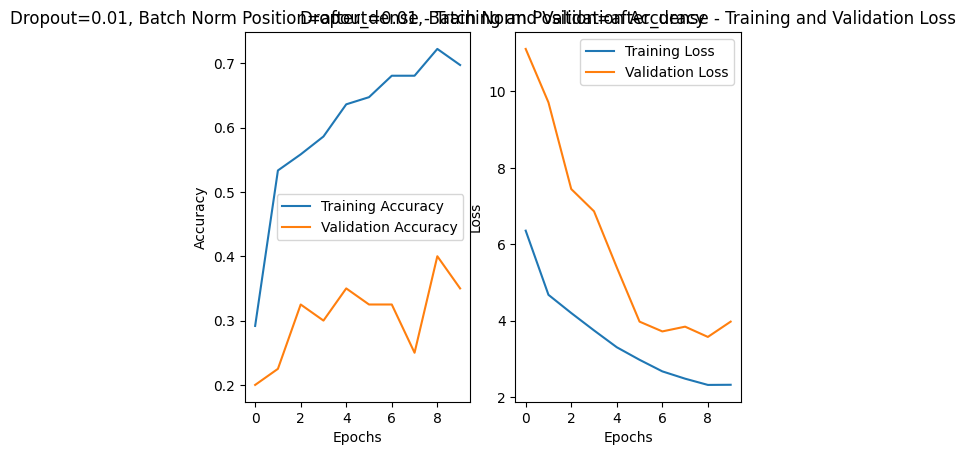

In [12]:
        # Save plots
        #plt.figure(figsize=(12, 6))

        # Plot training and validation accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title(f'{configuration_name} - Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        # Plot training and validation loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'{configuration_name} - Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        # Save the figure
       # plt.tight_layout()
       # plt.savefig(os.path.join(output_dir, f'training_curves_{configuration_name}.png'))
       # plt.close()  # Close the figure to free up resources

        # Evaluation
        test_images_preprocessed = [img.resize(target_size) for img in test_images]
        test_images_array = np.array([np.array(img) / 255.0 for img in test_images_preprocessed])

        test_labels = to_categorical(le.transform(test_data['genre']))
        accuracy = model.evaluate(test_images_array, test_labels)
        print(f'Test Accuracy: {accuracy[1]}')


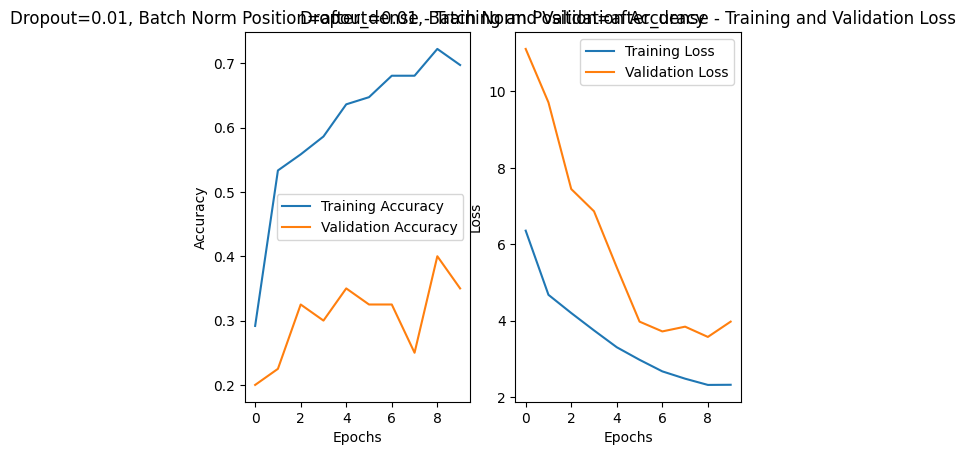

In [13]:
        # Plot training and validation accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title(f'{configuration_name} - Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        # Plot training and validation loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'{configuration_name} - Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint
import shutil

# Refined configurations
refined_dropout_rates = [0.01]  # Adjust as needed
refined_batch_norm_positions = ['after_dense']  # Adjust as needed

# Best model and its accuracy
best_model = None
best_accuracy = 0.0


# Fine-Tuning: Iterate over refined configurations
for refined_dropout_rate in refined_dropout_rates:
    for refined_batch_norm_position in refined_batch_norm_positions:
        # Build the refined model
        refined_model = Sequential()
        refined_model.add(base_model)
        refined_model.add(Flatten())
        refined_model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))

        if refined_batch_norm_position == 'before_dense':
            refined_model.add(BatchNormalization())

        refined_model.add(Dropout(refined_dropout_rate))

        if refined_batch_norm_position == 'after_dense':
            refined_model.add(BatchNormalization())

        refined_model.add(Dense(num_classes, activation='softmax'))

        # Transfer Learning
        base_model.trainable = False

        # Compile the refined Model
        refined_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

        # Print the refined configuration for reference
        refined_configuration_name = f"Refined_Dropout={refined_dropout_rate}, Batch Norm Position={refined_batch_norm_position}"
        print(f"Refined Configuration: {refined_configuration_name}")

        # Fine-Tuning: Continue Training and Evaluation
        history = refined_model.fit(train_generator, epochs=10, validation_data=(valid_images_array, valid_labels),
                                    callbacks=[early_stopping])

        # Evaluate the refined model
        accuracy = refined_model.evaluate(test_images_array, test_labels)
        print(f'Test Accuracy: {accuracy[1]}')

        # Save the refined model
        refined_model.save(os.path.join(output_dir, f'model_{refined_configuration_name}.h5'))

        # Save the training history
        history_df = pd.DataFrame(history.history)
        history_df.to_csv(os.path.join(output_dir, f'training_history_{refined_configuration_name}.csv'), index=False)

        # Save plots for the refined model
        plt.figure(figsize=(12, 6))

        # Plot training and validation accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title(f'{refined_configuration_name} - Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()

        # Plot training and validation loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'{refined_configuration_name} - Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()

        # Save the figure
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'training_curves_{refined_configuration_name}.png'))
        plt.close()  # Close the figure to free up resources


Refined Configuration: Refined_Dropout=0.01, Batch Norm Position=after_dense
Epoch 1/10
12/12 [==============================] - 253s 21s/step - loss: 7.2896 - accuracy: 0.2472 - val_loss: 7.0173 - val_accuracy: 0.2500
Epoch 2/10
12/12 [==============================] - 251s 21s/step - loss: 6.3205 - accuracy: 0.4861 - val_loss: 6.7528 - val_accuracy: 0.2250
Epoch 3/10
12/12 [==============================] - 233s 19s/step - loss: 5.7268 - accuracy: 0.5250 - val_loss: 6.3733 - val_accuracy: 0.2750
Epoch 4/10
12/12 [==============================] - 249s 21s/step - loss: 5.4182 - accuracy: 0.5722 - val_loss: 6.1051 - val_accuracy: 0.3250
Epoch 5/10
12/12 [==============================] - 248s 21s/step - loss: 5.1425 - accuracy: 0.6000 - val_loss: 5.9660 - val_accuracy: 0.2750
Epoch 6/10
12/12 [==============================] - 248s 21s/step - loss: 4.8418 - accuracy: 0.6278 - val_loss: 5.8420 - val_accuracy: 0.2250
Epoch 7/10
12/12 [==============================] - 248s 21s/step - los

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [15]:
# Save the best model based on validation accuracy
if accuracy[1] > best_accuracy:
    best_accuracy = accuracy[1]
    best_model = refined_model

# Save the overall best model
if best_model is not None:
    best_model.save(os.path.join(output_dir, 'best_model.h5'))

# Documentation: Update the documentation with details about refined configurations and results
with open(os.path.join(output_dir, 'documentation.txt'), 'a') as doc_file:
    doc_file.write('\n\nFine-Tuned Configurations and Results:\n')
    for refined_dropout_rate in refined_dropout_rates:
        for refined_batch_norm_position in refined_batch_norm_positions:
            refined_configuration_name = f"Refined_Dropout={refined_dropout_rate}, Batch Norm Position={refined_batch_norm_position}"
            doc_file.write(f'\nConfiguration: {refined_configuration_name}\n')

            # Load training history for refined configuration
            refined_history = pd.read_csv(os.path.join(output_dir, f'training_history_{refined_configuration_name}.csv'))
            # Write details to documentation
            doc_file.write(f'Max Validation Accuracy: {refined_history["val_accuracy"].max()}\n')
            doc_file.write(f'Test Accuracy: {best_accuracy}\n')
            doc_file.write(f'Training History:\n{refined_history.to_string(index=False)}\n')
            # Including the configuration details of hyperparameters.
            doc_file.write(f'Refined Dropout Rate: {refined_dropout_rate}\n')
            doc_file.write(f'Refined Batch Norm Position: {refined_batch_norm_position}\n')

            # Fine-tuning after the initial training
            # Unfreeze some layers for fine-tuning
            base_model.trainable = True

            # Freeze layers until the last few
            fine_tune_at = len(base_model.layers) - 10
            for layer in base_model.layers[:fine_tune_at]:
                layer.trainable = False

            # Compile the model again for fine-tuning
            refined_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

            # Fine-tuning training
            history_fine_tune = refined_model.fit(train_generator, epochs=5, validation_data=(valid_images_array, valid_labels),
                                                  callbacks=[early_stopping])

            # Save the refined model after fine-tuning
            refined_model.save(os.path.join(output_dir, f'model_{refined_configuration_name}_fine_tuned.h5'))

            # Save the training history after fine-tuning
            history_fine_tune_df = pd.DataFrame(history_fine_tune.history)
            history_fine_tune_df.to_csv(os.path.join(output_dir, f'training_history_{refined_configuration_name}_fine_tuned.csv'), index=False)

            # Save plots for the refined model after fine-tuning
            plt.figure(figsize=(12, 6))

            # Plot training and validation accuracy
            plt.subplot(1, 2, 1)
            plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy (Fine-tuned)')
            plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy (Fine-tuned)')
            plt.title(f'{refined_configuration_name} - Training and Validation Accuracy (Fine-tuned)')
            plt.xlabel('Epochs')
            plt.ylabel('Accuracy')
            plt.legend()

            # Plot training and validation loss
            plt.subplot(1, 2, 2)
            plt.plot(history_fine_tune.history['loss'], label='Training Loss (Fine-tuned)')
            plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss (Fine-tuned)')
            plt.title(f'{refined_configuration_name} - Training and Validation Loss (Fine-tuned)')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()

            # Save the figure for the fine-tuned model
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'training_curves_{refined_configuration_name}_fine_tuned.png'))
            plt.close()  # Close the figure to free up resources


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/5
12/12 [==============================] - 467s 38s/step - loss: 4.6442 - accuracy: 0.5250 - val_loss: 6.6399 - val_accuracy: 0.2500
Epoch 2/5
12/12 [==============================] - 472s 39s/step - loss: 4.2475 - accuracy: 0.5917 - val_loss: 5.4607 - val_accuracy: 0.2500
Epoch 3/5
12/12 [==============================] - 473s 39s/step - loss: 3.8780 - accuracy: 0.6194 - val_loss: 5.0740 - val_accuracy: 0.3000
Epoch 4/5
12/12 [==============================] - 471s 39s/step - loss: 3.6872 - accuracy: 0.6056 - val_loss: 5.2371 - val_accuracy: 0.2500
Epoch 5/5
12/12 [==============================] - 473s 39s/step - loss: 3.3644 - accuracy: 0.6694 - val_loss: 5.2699 - val_accuracy: 0.3500


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


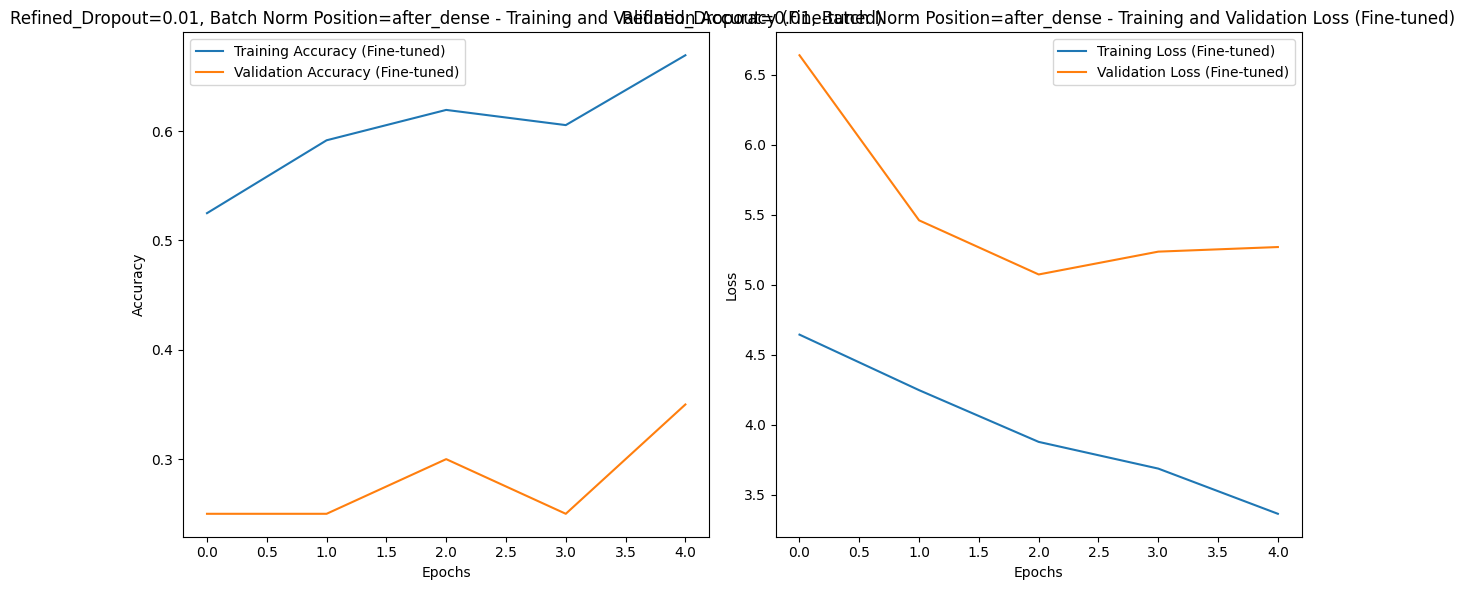

In [28]:
# Save plots for the refined model after fine-tuning
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy (Fine-tuned)')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy (Fine-tuned)')
plt.title(f'{refined_configuration_name} - Training and Validation Accuracy (Fine-tuned)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'], label='Training Loss (Fine-tuned)')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss (Fine-tuned)')
plt.title(f'{refined_configuration_name} - Training and Validation Loss (Fine-tuned)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the figure for the fine-tuned model directly in the notebook
plt.tight_layout()
plt.show()


4/4 [==============================] - 63s 13s/step
Classification Report:
               precision    recall  f1-score   support

           0       0.00      1.00      0.00         0
           1       1.00      0.00      0.00         5
           2       0.20      1.00      0.33        11
           3       0.00      0.00      0.00         1
           4       0.59      0.43      0.50        23
           5       1.00      0.00      0.00         4
           6       0.55      0.33      0.41        18
           7       0.50      0.14      0.22         7
           8       1.00      0.20      0.33        10
           9       1.00      0.00      0.00         4
          10       0.22      0.12      0.15        17

    accuracy                           0.32       100
   macro avg       0.55      0.29      0.18       100
weighted avg       0.56      0.32      0.30       100



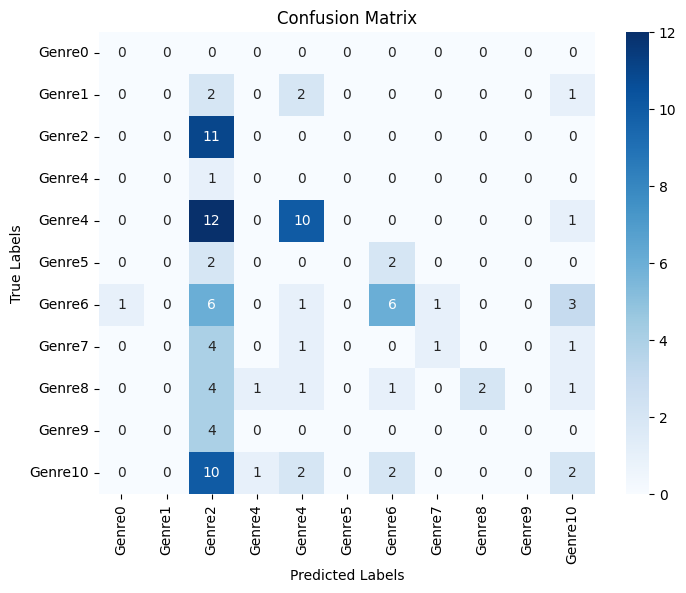

In [18]:
# Refined_model is the best model from your fine-tuning process

predictions = best_model.predict(test_images_array)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Generate Classification Report
from sklearn.metrics import classification_report
print("Classification Report:\n", classification_report(true_labels, predicted_labels, zero_division=1))

# Generate Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define genres (replace with your actual genre labels)
genres = ['Genre0', 'Genre1', 'Genre2','Genre4', 'Genre4', 'Genre5', 'Genre6', 'Genre7', 'Genre8','Genre9', 'Genre10']

conf_matrix = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


4/4 [==============================] - 70s 17s/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


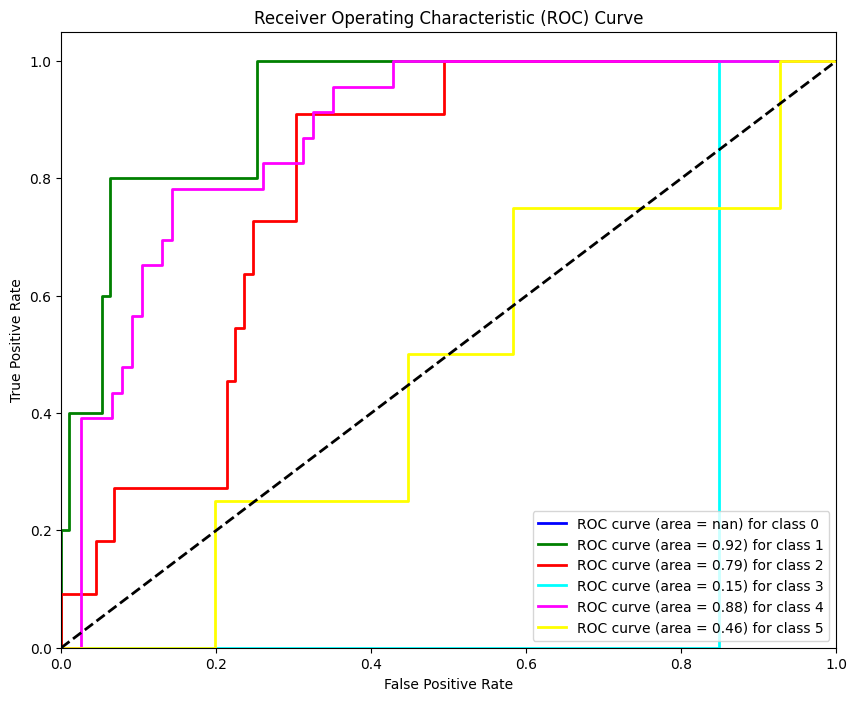

In [19]:
# Implementing Receiver Operating Characteristic (ROC)

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Refined_model is the best model from your fine-tuning process
y_score = refined_model.predict(test_images_array)

# Binarize the labels
y_test_bin = label_binarize(true_labels, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

n_classes = num_classes  # Update with the actual number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve (area = {roc_auc[i]:.2f}) for class {i}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [20]:
#Printing the model summary and key configuration details
#best_model
print(refined_model.summary())
print(f"Number of trainable parameters: {np.sum([np.prod(v.get_shape().as_list()) for v in refined_model.trainable_variables])}")


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 25088)             0         
                                                                 
 dense_4 (Dense)             (None, 256)               6422784   
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 batch_normalization_2 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_5 (Dense)             (None, 11)                2827      
                                                      

In [24]:
#Printing the Best model summary and key configuration details

print(my_model.summary())
print(f"Number of trainable parameters: {np.sum([np.prod(v.get_shape().as_list()) for v in my_model.trainable_variables])}")


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 25088)             0         
                                                                 
 dense_2 (Dense)             (None, 256)               6422784   
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 11)                2827      
                                                      

In [21]:
print(history.history)

{'loss': [7.289638042449951, 6.320498466491699, 5.726822376251221, 5.418165683746338, 5.142484664916992, 4.841838359832764, 4.604364395141602, 4.509307384490967, 4.2933349609375, 4.151840686798096], 'accuracy': [0.24722221493721008, 0.4861111044883728, 0.5249999761581421, 0.5722222328186035, 0.6000000238418579, 0.6277777552604675, 0.6694444417953491, 0.6666666865348816, 0.7194444537162781, 0.699999988079071], 'val_loss': [7.017279148101807, 6.752750396728516, 6.373332977294922, 6.105144500732422, 5.966020107269287, 5.842001914978027, 5.527543544769287, 5.321434020996094, 5.216954708099365, 5.127535820007324], 'val_accuracy': [0.25, 0.22499999403953552, 0.2750000059604645, 0.32499998807907104, 0.2750000059604645, 0.22499999403953552, 0.30000001192092896, 0.4000000059604645, 0.32499998807907104, 0.3499999940395355]}


In [22]:
#Verify the Saving of Models
import os
print(os.listdir(output_dir))  # List files in the output directory


['model_Dropout=0.05, Batch Norm Position=after_dense.h5', 'training_history_Dropout=0.05, Batch Norm Position=after_dense.csv', 'training_curves_Dropout=0.05, Batch Norm Position=after_dense.png', 'model_Dropout=0.01, Batch Norm Position=after_dense.h5', 'training_history_Dropout=0.01, Batch Norm Position=after_dense.csv', 'training_curves_Dropout=0.01, Batch Norm Position=after_dense.png', 'model_Refined_Dropout=0.01, Batch Norm Position=after_dense.h5', 'training_history_Refined_Dropout=0.01, Batch Norm Position=after_dense.csv', 'training_curves_Refined_Dropout=0.01, Batch Norm Position=after_dense.png', 'best_model.h5', 'documentation.txt', 'model_Refined_Dropout=0.01, Batch Norm Position=after_dense_fine_tuned.h5', 'training_history_Refined_Dropout=0.01, Batch Norm Position=after_dense_fine_tuned.csv', 'training_curves_Refined_Dropout=0.01, Batch Norm Position=after_dense_fine_tuned.png']
